In [5]:

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


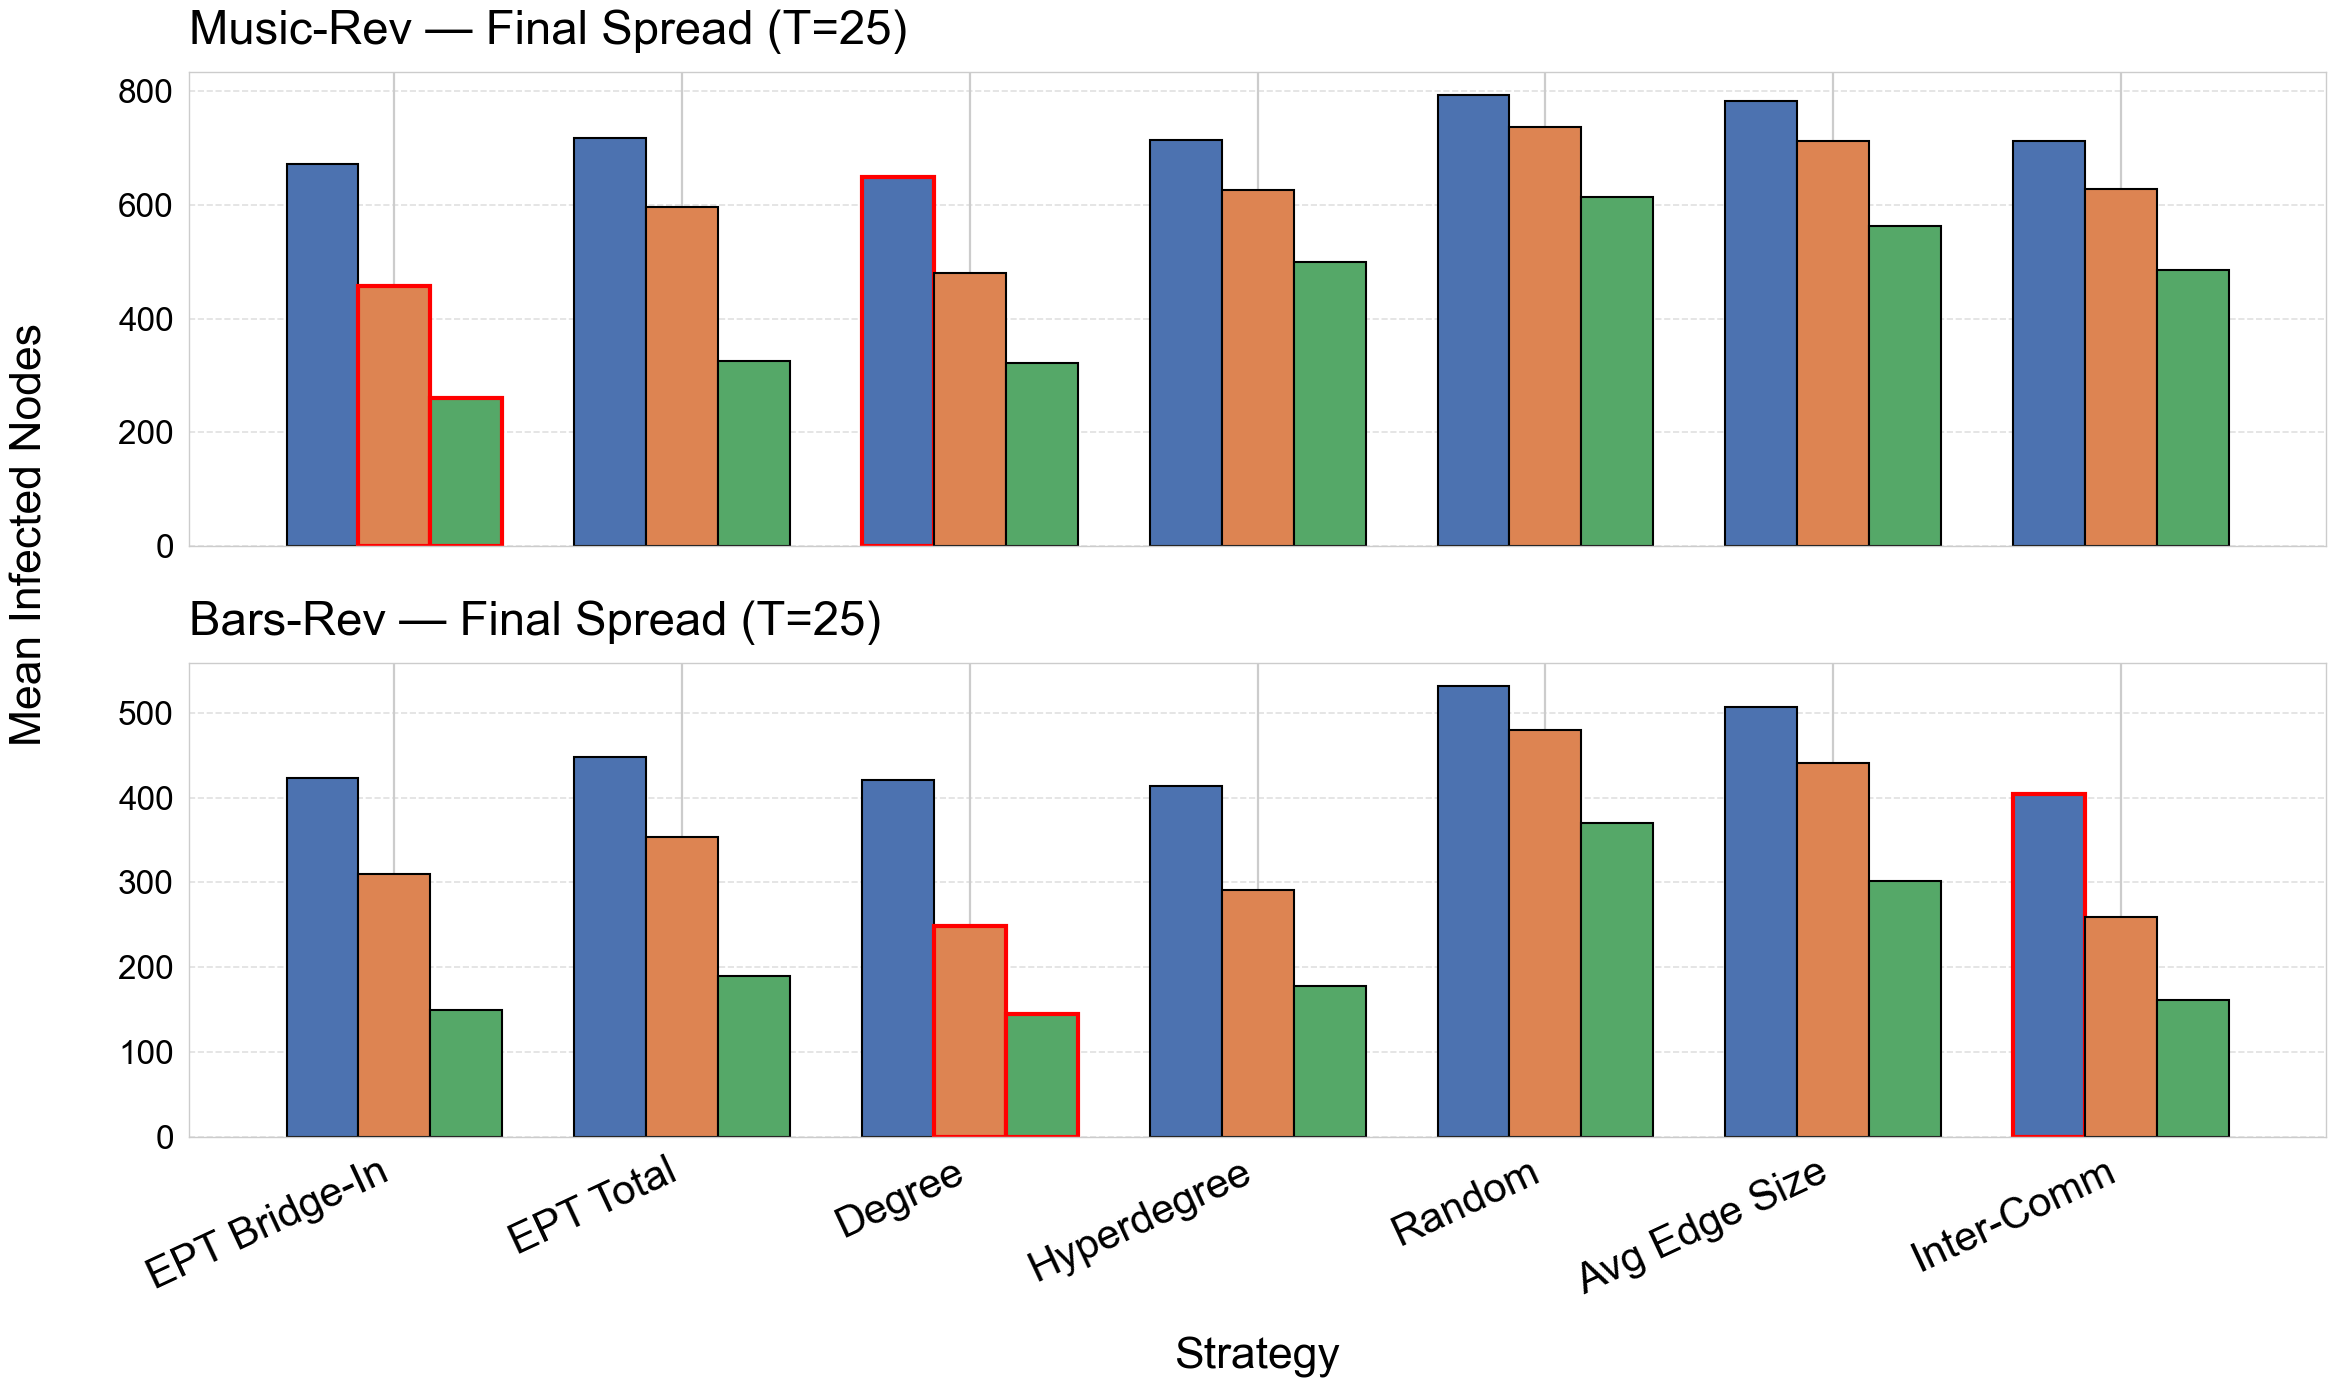

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Load BOTH datasets
# ---------------------------
music_path = "../outputs/music_rev_constructed_poster_data.csv"
bars_path = "../outputs/bars_rev_constructed_poster_data.csv"

df_music = pd.read_csv(music_path)
df_bars = pd.read_csv(bars_path)

# ---------------------------
# Preprocessing
# ---------------------------
def prepare(df, dataset_name):
    df = df[df["dataset"] == dataset_name].copy()
    df["p"] = df["p"].astype(float)
    df["timestep"] = df["timestep"].astype(int)
    df["mean_infected"] = df["mean_infected"].astype(float)

    final_t = df["timestep"].max()
    final = df[df["timestep"] == final_t].copy()

    pivot = (final
             .pivot_table(index="strategy", columns="p",
                          values="mean_infected", aggfunc="mean"))
    return final_t, pivot

t_music, pivot_music = prepare(df_music, "Music-Rev")
t_bars, pivot_bars = prepare(df_bars, "Bars-Rev")

# ---------------------------
# Shared strategy order
# ---------------------------
strategy_order = [
    "ept_bridge_in_strength",
    "ept_total_strength",
    "degree",
    "hyperdegree",
    "random",
    "avg_hyperedge_size",
    "ic_hedge_count",
]

common = list(set(pivot_music.index) & set(pivot_bars.index))
strategy_order = [s for s in strategy_order if s in common]

pivot_music = pivot_music.reindex(strategy_order)
pivot_bars = pivot_bars.reindex(strategy_order)

p_order = sorted(pivot_music.columns)

# ---------------------------
# Styling
# ---------------------------
plt.style.use("seaborn-v0_8-poster")
plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 34,
    "axes.labelsize": 32,
    "xtick.labelsize": 28,
    "ytick.labelsize": 24,
    "legend.fontsize": 20,
})

fig_width = max(24, 3 * len(strategy_order))
fig, axs = plt.subplots(2, 1, figsize=(fig_width, 16), sharex=True)

fig.patch.set_alpha(0.0)

for ax in axs:
    ax.set_facecolor("none")
    ax.grid(axis="y", linestyle="--", linewidth=1.2, alpha=0.6)  # stronger grid
    ax.tick_params(colors="black")

x = np.arange(len(strategy_order))
bar_w = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

# ---------------------------
# Plot function with red-outline logic
# ---------------------------
def plot_dataset(ax, pivot, title, final_t):
    for j, p_val in enumerate(p_order):
        y = pivot[p_val].values

        # Find best (lowest infection)
        min_idx = np.argmin(y)

        for i, val in enumerate(y):
            offset = (j - (len(p_order) - 1)/2) * bar_w

            edge_color = "black"
            lw = 1.5

            if i == min_idx:  # BEST strategy → highlight
                edge_color = "red"
                lw = 3.0

            ax.bar(
                x[i] + offset,
                val,
                width=bar_w,
                color=colors[j],
                edgecolor=edge_color,
                linewidth=lw
            )

    # Title moved left
    ax.set_title(title, loc="left", pad=20, color="black")

# ---------------------------
# Plot datasets
# ---------------------------
plot_dataset(axs[0], pivot_music, f"Music-Rev — Final Spread (T={t_music})", t_music)
plot_dataset(axs[1], pivot_bars, f"Bars-Rev — Final Spread (T={t_bars})", t_bars)

# ---------------------------
# Shared X labels
# ---------------------------
pretty_names = {
    "degree": "Degree",
    "hyperdegree": "Hyperdegree",
    "random": "Random",
    "ept_total_strength": "EPT Total",
    "ept_bridge_in_strength": "EPT Bridge-In",
    "avg_hyperedge_size": "Avg Edge Size",
    "ic_hedge_count": "Inter-Comm",
}

labels = [pretty_names.get(s, s) for s in strategy_order]

axs[1].set_xticks(x)
axs[1].set_xticklabels(labels, rotation=25, ha="right", fontsize=30, color="black")
axs[1].set_xlabel("Strategy", labelpad=25, color="black")

# ---------------------------
# Single shared Y label (fixed overlap)
# ---------------------------
fig.text(
    0.02, 0.55,
    "Mean Infected Nodes",
    va='center',
    rotation='vertical',
    fontsize=32,
    color="black"
)

# ---------------------------
# Legend (top-right, clean)
# ---------------------------
handles = [
    plt.Rectangle((0,0),1,1,color=colors[i])
    for i in range(len(p_order))
]

axs[0].legend(
    handles,
    [f"p={p:.2f}" for p in p_order],
    title="Removal fraction",
    loc="upper right",
    bbox_to_anchor=(1.02, 1.10),
    frameon=False
)

# ---------------------------
# Layout tuning
# ---------------------------
plt.subplots_adjust(top=0.88, hspace=0.30, left=0.08)
plt.tight_layout(rect=[0.05, 0, 1, 0.90])

# ---------------------------
# Save
# ---------------------------
plt.savefig(
    "combined_music_bars_rev_poster.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()


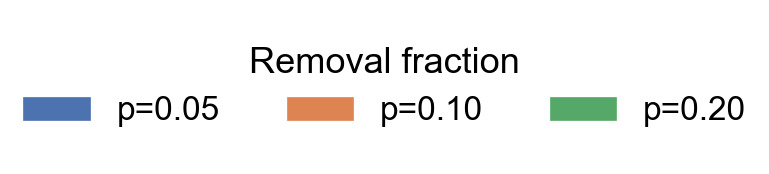

In [9]:
import matplotlib.pyplot as plt

# Same colors and labels as your main plot
p_order = [0.05, 0.10, 0.20]
colors = ["#4C72B0", "#DD8452", "#55A868"]

labels = [f"p={p:.2f}" for p in p_order]

# Create dummy handles
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[i])
    for i in range(len(labels))
]

# Create small figure just for legend
fig, ax = plt.subplots(figsize=(6, 2))

# Remove axes
ax.axis("off")

# Add legend
legend = ax.legend(
    handles,
    labels,
    title="Removal fraction",
    loc="center",
    frameon=False,
    ncol=3,
    fontsize=24,
    title_fontsize=26
)

# Transparent background
fig.patch.set_alpha(0.0)

# Save separately
plt.savefig(
    "legend_removal_fraction.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

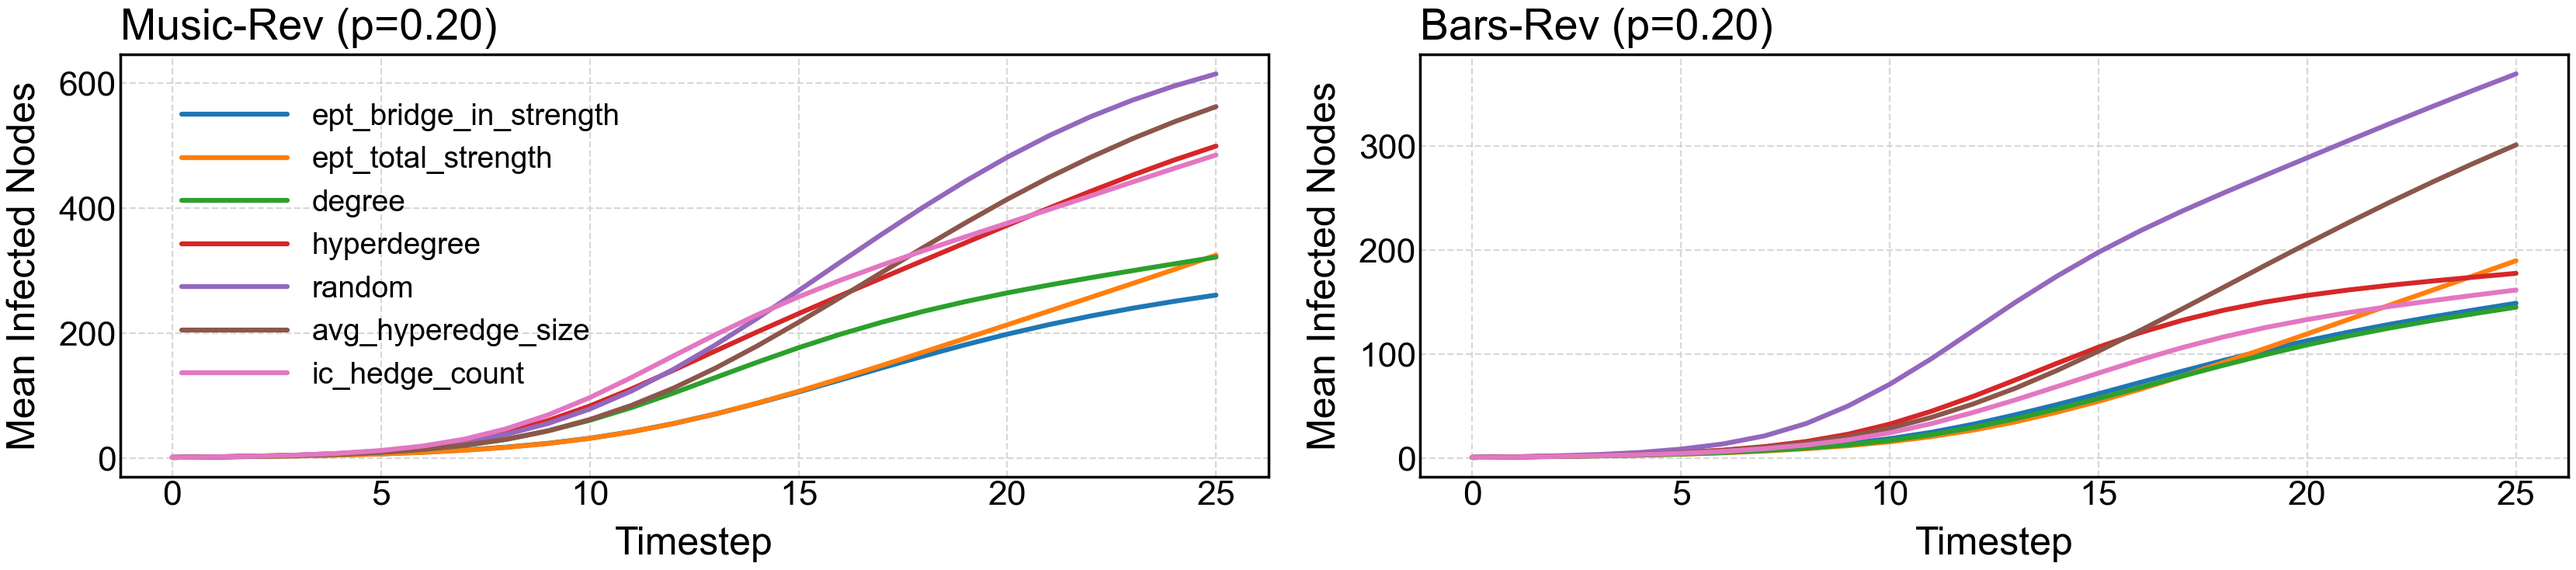

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Load data
# ---------------------------
music_path = "../outputs/music_rev_constructed_poster_data.csv"
bars_path = "../outputs/bars_rev_constructed_poster_data.csv"

df_music = pd.read_csv(music_path)
df_bars = pd.read_csv(bars_path)

# ---------------------------
# Preprocessing
# ---------------------------
def prepare(df, dataset_name):
    df = df[df["dataset"] == dataset_name].copy()
    df["p"] = df["p"].astype(float)
    df["timestep"] = df["timestep"].astype(int)
    df["mean_infected"] = df["mean_infected"].astype(float)
    return df

df_music = prepare(df_music, "Music-Rev")
df_bars  = prepare(df_bars,  "Bars-Rev")

# ---------------------------
# Choose ONE removal fraction
# ---------------------------
PLOT_P = 0.2

df_music = df_music[df_music["p"] == PLOT_P]
df_bars  = df_bars[df_bars["p"] == PLOT_P]

# ---------------------------
# Strategy order
# ---------------------------
strategy_order = [
    "ept_bridge_in_strength",
    "ept_total_strength",
    "degree",
    "hyperdegree",
    "random",
    "avg_hyperedge_size",
    "ic_hedge_count",
]

common = list(set(df_music["strategy"]) & set(df_bars["strategy"]))
strategy_order = [s for s in strategy_order if s in common]

# ---------------------------
# Styling (LARGER POSTER SCALE)
# ---------------------------
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 34,          # ↑ bigger
    "axes.titlesize": 40,
    "axes.labelsize": 36,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 28,

    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

# ---------------------------
# Create figure (WIDE + SLIMMER)
# ---------------------------
fig, axs = plt.subplots(1, 2, figsize=(34, 8.5))  # ↓ height reduced (~80%)

# Transparent background
fig.patch.set_alpha(0.0)
for ax in axs:
    ax.set_facecolor("none")

colors = plt.get_cmap("tab10").colors

# ---------------------------
# Plot function
# ---------------------------
def plot_timeseries(ax, df, title):
    for i, strategy in enumerate(strategy_order):
        sub = df[df["strategy"] == strategy]
        if sub.empty:
            continue

        ax.plot(
            sub["timestep"],
            sub["mean_infected"],
            linewidth=4.5,   # thicker lines for visibility
            color=colors[i % len(colors)],
            label=strategy
        )

    ax.set_title(title, loc="left", pad=14)
    ax.set_xlabel("Timestep", labelpad=14)
    ax.set_ylabel("Mean Infected Nodes", labelpad=14)

    # Strong grid
    ax.grid(True, linestyle="--", linewidth=1.6, alpha=0.75)

    # Thick borders
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color("black")

    ax.tick_params(colors="black", width=1.8)

# ---------------------------
# Plot both datasets
# ---------------------------
plot_timeseries(
    axs[0],
    df_music,
    f"Music-Rev (p={PLOT_P:.2f})"
)

plot_timeseries(
    axs[1],
    df_bars,
    f"Bars-Rev (p={PLOT_P:.2f})"
)

# ---------------------------
# Legend (LEFT plot, clearly below title)
# ---------------------------
axs[0].legend(
    loc="upper left",
    bbox_to_anchor=(0.03, 0.95),
    frameon=False,
    handlelength=3.5
)

# ---------------------------
# Layout
# ---------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])

# ---------------------------
# Save
# ---------------------------
plt.savefig(
    "timeseries_music_vs_bars_final.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()